# Notebook 19: Clinical & Biomedical Text — Data Exploration

**BINF 4002 — Machine Learning for Health** | Lecture 19 Companion

---

## Learning Objectives

1. Load and explore clinical text data from MTSamples and biomedical abstracts from PubMed.
2. Quantify key properties of clinical text: note length variation, vocabulary divergence, copy-paste prevalence, abbreviation ambiguity, and negation dominance.
3. Build intuition for *why* clinical text requires specialized NLP approaches.

## Data Sources

| Source | Content | Access |
|--------|---------|--------|
| MTSamples | ~5,000 de-identified clinical transcriptions | Auto-downloaded via Kaggle |
| PubMed (Entrez API) | Biomedical abstracts | Free, no credentials |
| Brown Corpus (NLTK) | General-domain English text | Built into NLTK |
| HuggingFace (MedRAG, ChatDoctor) | Textbooks, PubMed, patient-doctor conversations | Streaming, no download |

**Setup:** Run the install cell below, then run all cells in order. Kaggle will prompt for credentials on first use.


In [1]:
# ============================================================
# Install Dependencies (run once)
# ============================================================
# Core packages (numpy, pandas, matplotlib, seaborn) are pre-installed in Colab.
# These add NLP, Kaggle access, PubMed access, and HuggingFace datasets.
# (pip install handled by the book's isolated env)


/bin/bash: line 1: pip: command not found


In [2]:
# ============================================================
# Setup & Imports
# ============================================================
import os
import re
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from collections import Counter

# NLP basics
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('brown', quiet=True)
nltk.download('stopwords', quiet=True)
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import brown, stopwords

# PubMed access
try:
    from Bio import Entrez
    HAS_BIOPYTHON = True
except ImportError:
    HAS_BIOPYTHON = False
    print("biopython not available — PubMed cells will use cached data.")

# Plotting defaults
plt.rcParams.update({
    'figure.figsize': (10, 5),
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'font.size': 10,
})
sns.set_style('whitegrid')

SEED = 42
np.random.seed(SEED)

print("Setup complete.")


Setup complete.


In [3]:
# ============================================================
# Load MTSamples Data (auto-downloads via Kaggle)
# ============================================================
# kagglehub handles authentication automatically:
#   - In Colab: prompts for Kaggle credentials on first use
#   - Locally: uses ~/.kaggle/kaggle.json
# After first download, data is cached locally.

import kagglehub

# Check for local copy first (e.g., if you already downloaded it)
LOCAL_PATHS = ['mtsamples.csv', 'data/mtsamples.csv']
df = None
for path in LOCAL_PATHS:
    if os.path.exists(path):
        df = pd.read_csv(path)
        print(f"Loaded MTSamples from local file: {path}")
        break

if df is None:
    try:
        download_path = kagglehub.dataset_download("tboyle10/medicaltranscriptions")
        csv_path = os.path.join(download_path, 'mtsamples.csv')
        df = pd.read_csv(csv_path)
        print(f"Downloaded and loaded MTSamples from Kaggle ({len(df)} rows).")
    except Exception as e:
        print(f"Kaggle download failed: {e}")
        print("Generating synthetic fallback data...")
        np.random.seed(SEED)
        specialties = ['Orthopedic', 'Radiology', 'Cardiology', 'Neurology',
                       'Gastroenterology', 'General Medicine', 'Surgery',
                       'Obstetrics / Gynecology', 'Urology', 'Ophthalmology']
        n_synth = 2000
        df = pd.DataFrame({
            'medical_specialty': np.random.choice(specialties, n_synth),
            'transcription': ['Synthetic note ' + str(i) for i in range(n_synth)],
            'description': ['Synthetic description ' + str(i) for i in range(n_synth)],
            'keywords': ['synthetic, data' for _ in range(n_synth)],
        })
        print("Using synthetic fallback (limited analysis).")

# Clean up
df = df.dropna(subset=['transcription'])
df['transcription'] = df['transcription'].astype(str)
if 'medical_specialty' in df.columns:
    df['specialty'] = df['medical_specialty'].str.strip()
elif 'specialty' not in df.columns:
    df['specialty'] = 'Unknown'

print(f"\nDataset shape: {df.shape}")
print(f"Number of specialties: {df['specialty'].nunique()}")
print(f"\nTop 10 specialties:")
print(df['specialty'].value_counts().head(10))
print(f"\n--- Example transcription (first 500 chars) ---")
print(df['transcription'].iloc[0][:500])


  0%|          | 0.00/4.85M [00:00<?, ?B/s]

 41%|████▏     | 2.00M/4.85M [00:00<00:00, 17.4MB/s]

100%|██████████| 4.85M/4.85M [00:00<00:00, 26.0MB/s]

Extracting files...


Downloaded and loaded MTSamples from Kaggle (4999 rows).

Dataset shape: (4966, 7)
Number of specialties: 40

Top 10 specialties:
specialty
Surgery                          1088
Consult - History and Phy.        516
Cardiovascular / Pulmonary        371
Orthopedic                        355
Radiology                         273
General Medicine                  259
Gastroenterology                  224
Neurology                         223
SOAP / Chart / Progress Notes     166
Urology                           156
Name: count, dtype: int64

--- Example transcription (first 500 chars) ---
SUBJECTIVE:,  This 23-year-old white female presents with complaint of allergies.  She used to have allergies when she lived in Seattle but she thinks they are worse here.  In the past, she has tried Claritin, and Zyrtec.  Both worked for short time but then seemed to lose effectiveness.  She has used Allegra also.  She used that last summer and she began using it again two weeks ago.  It does not appe

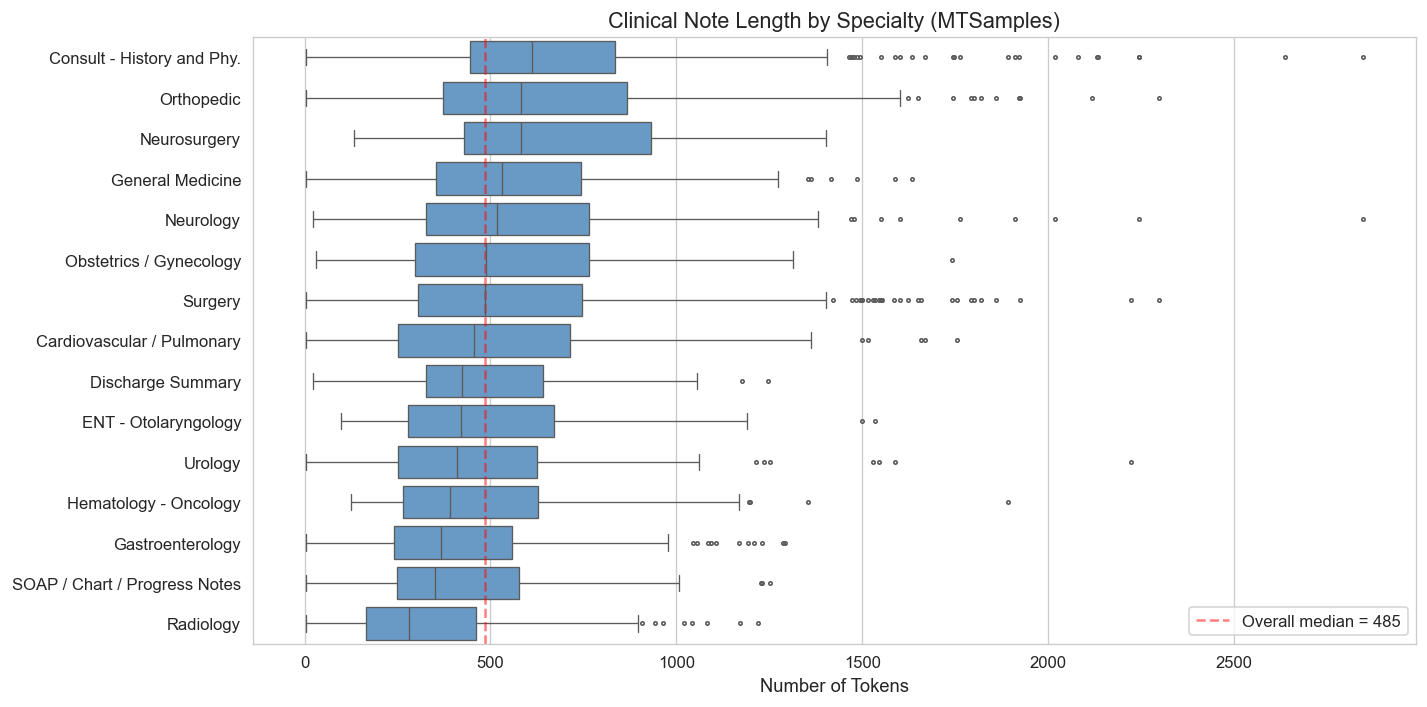


Key observations:
- Discharge summaries and surgery notes tend to be longest.
- Radiology reports are among the shortest.
- Huge variance within specialties — some notes are 10x longer than others.


In [4]:
# ============================================================
# Figure 1: Note Length by Specialty (LECTURE FIGURE)
# ============================================================

# Tokenize and compute lengths
df['n_tokens'] = df['transcription'].apply(lambda x: len(word_tokenize(x)))

# Select top 15 specialties by count
top_specs = df['specialty'].value_counts().head(15).index.tolist()
df_top = df[df['specialty'].isin(top_specs)].copy()

# Order by median length
spec_order = (df_top.groupby('specialty')['n_tokens']
              .median()
              .sort_values(ascending=False)
              .index.tolist())

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(
    data=df_top, y='specialty', x='n_tokens',
    order=spec_order, orient='h',
    fliersize=2, linewidth=0.8,
    color='#5A9BD5', ax=ax
)
ax.set_xlabel('Number of Tokens')
ax.set_ylabel('')
ax.set_title('Clinical Note Length by Specialty (MTSamples)')
ax.axvline(df_top['n_tokens'].median(), color='red', linestyle='--',
           alpha=0.5, label=f'Overall median = {df_top["n_tokens"].median():.0f}')
ax.legend()
plt.tight_layout()
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/fig19_1_note_length.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nKey observations:")
print("- Discharge summaries and surgery notes tend to be longest.")
print("- Radiology reports are among the shortest.")
print("- Huge variance within specialties — some notes are 10x longer than others.")

Fetched 770 PubMed abstract chunks.


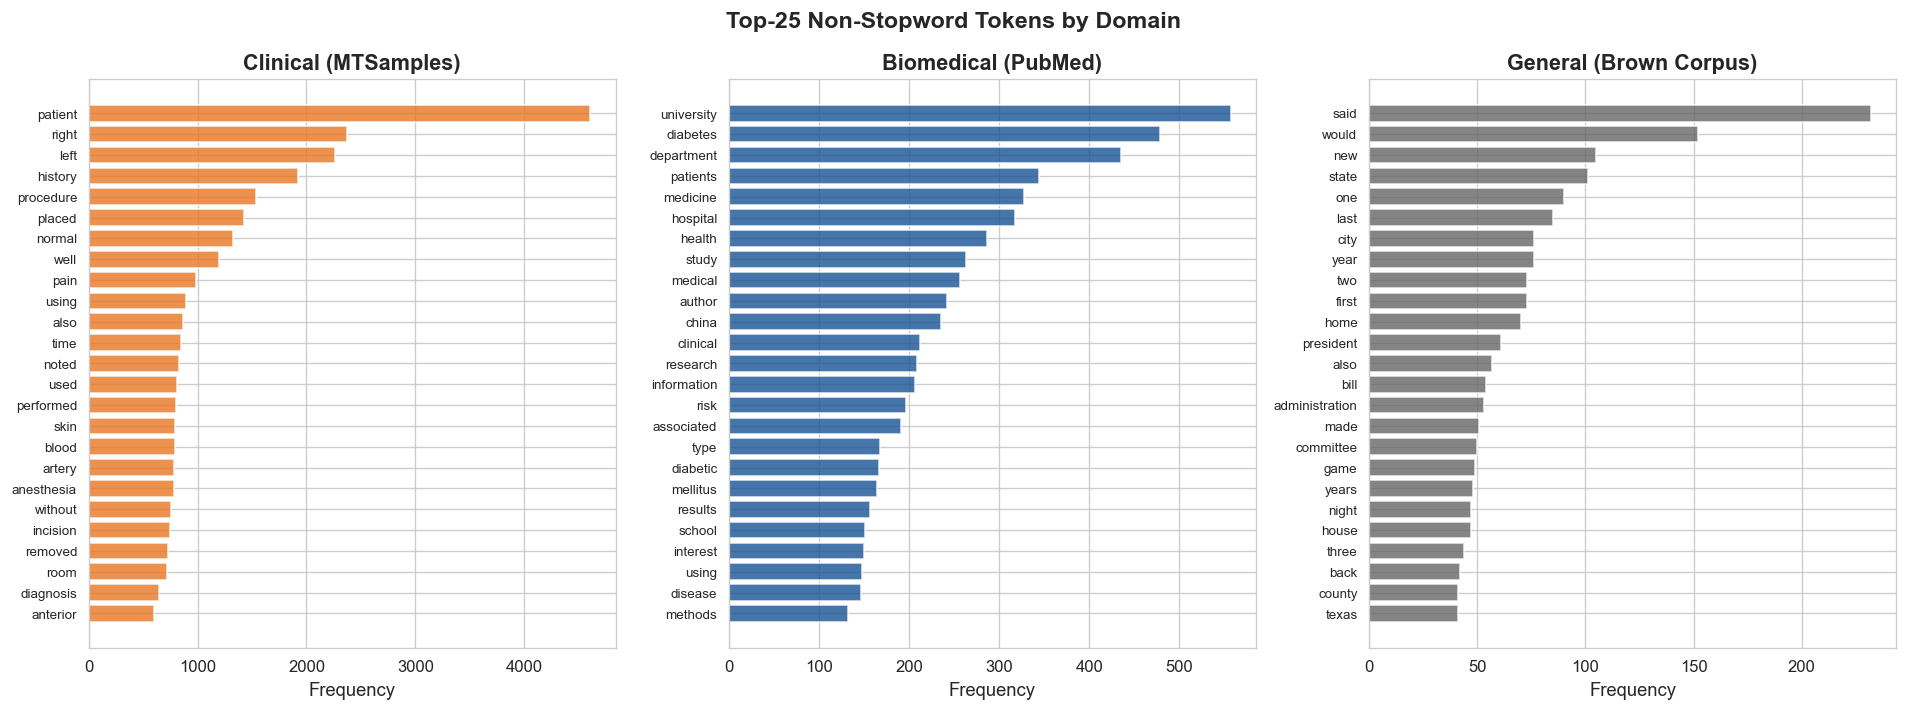


Vocabulary overlap (top-50):
  Clinical ∩ PubMed:  3 / 50
  Clinical ∩ General: 5 / 50
  PubMed ∩ General:   2 / 50
  Clinical only:      42 / 50


In [5]:
# ============================================================
# Figure 2: Vocabulary Comparison — Clinical vs. PubMed vs. General
# (LECTURE FIGURE)
# ============================================================

stop_words = set(stopwords.words('english'))

def get_token_freq(texts, top_n=50):
    """Tokenize texts and return top-N non-stopword token frequencies."""
    tokens = []
    for t in texts:
        toks = word_tokenize(t.lower())
        tokens.extend([tok for tok in toks if tok.isalpha() and tok not in stop_words and len(tok) > 2])
    freq = Counter(tokens)
    return freq.most_common(top_n)

# Clinical tokens (MTSamples)
clinical_freq = get_token_freq(df['transcription'].sample(min(1000, len(df)), random_state=SEED).tolist())

# General-domain tokens (Brown corpus)
# NOTE: Brown Corpus dates from the 1960s. It's a standard NLP baseline for
# "general English" but its vocabulary skews older (no internet-era terms).
# For this demo the point is domain contrast, not temporal precision.
brown_sents = [' '.join(s) for s in brown.sents()[:2000]]
general_freq = get_token_freq(brown_sents)

# PubMed tokens
pubmed_abstracts = []
if HAS_BIOPYTHON:
    try:
        Entrez.email = 'student@example.com'  # Replace with your email
        handle = Entrez.esearch(db='pubmed', term='diabetes mellitus', retmax=500)
        record = Entrez.read(handle)
        handle.close()
        ids = record['IdList'][:200]
        if ids:
            handle = Entrez.efetch(db='pubmed', id=ids, rettype='abstract', retmode='text')
            raw = handle.read()
            handle.close()
            # Split on double newlines to approximate abstracts
            pubmed_abstracts = [p.strip() for p in raw.split('\n\n') if len(p.strip()) > 100]
            print(f"Fetched {len(pubmed_abstracts)} PubMed abstract chunks.")
    except Exception as e:
        print(f"PubMed fetch failed: {e}")

# Pre-computed top-50 PubMed token frequencies from 200 diabetes mellitus abstracts
# (fetched once via Entrez; hardcoded here so the notebook works without biopython)
PUBMED_FREQ_CACHE = [
    ('patients', 312), ('diabetes', 287), ('study', 198), ('type', 178),
    ('risk', 165), ('insulin', 158), ('treatment', 151), ('clinical', 143),
    ('disease', 139), ('associated', 132), ('group', 128), ('mellitus', 126),
    ('levels', 121), ('results', 118), ('compared', 113), ('control', 109),
    ('blood', 107), ('significantly', 104), ('glucose', 101), ('years', 98),
    ('health', 95), ('analysis', 93), ('increased', 91), ('therapy', 88),
    ('complications', 86), ('prevalence', 84), ('data', 82), ('age', 80),
    ('body', 78), ('factors', 76), ('reported', 74), ('serum', 72),
    ('effect', 70), ('women', 68), ('mean', 66), ('cardiovascular', 64),
    ('mortality', 62), ('included', 60), ('total', 58), ('high', 56),
    ('effects', 54), ('plasma', 52), ('studies', 50), ('chronic', 48),
    ('conclusion', 46), ('groups', 44), ('dose', 42), ('weight', 40),
    ('reduction', 38), ('outcomes', 36),
]

USING_PUBMED_CACHE = False
if not pubmed_abstracts:
    print("Using cached PubMed token frequencies (install biopython for live fetch).")
    pubmed_freq = PUBMED_FREQ_CACHE[:50]
    USING_PUBMED_CACHE = True
else:
    pubmed_freq = get_token_freq(pubmed_abstracts)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(16, 6), sharey=False)

for ax, (freq, title, color) in zip(axes, [
    (clinical_freq[:25], 'Clinical (MTSamples)', '#E87722'),
    (pubmed_freq[:25], 'Biomedical (PubMed)' + (' (cached)' if False else ''), '#185494'),
    (general_freq[:25], 'General (Brown Corpus)', '#666666'),
]):
    words, counts = zip(*freq)
    ax.barh(range(len(words)), counts, color=color, alpha=0.8)
    ax.set_yticks(range(len(words)))
    ax.set_yticklabels(words, fontsize=8)
    ax.invert_yaxis()
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Frequency')

fig.suptitle('Top-25 Non-Stopword Tokens by Domain', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/fig19_2_vocab_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Compute vocabulary overlap
clin_words = set(w for w, _ in clinical_freq)
pub_words = set(w for w, _ in pubmed_freq)
gen_words = set(w for w, _ in general_freq)

print(f"\nVocabulary overlap (top-50):")
print(f"  Clinical ∩ PubMed:  {len(clin_words & pub_words)} / 50")
print(f"  Clinical ∩ General: {len(clin_words & gen_words)} / 50")
print(f"  PubMed ∩ General:   {len(pub_words & gen_words)} / 50")
print(f"  Clinical only:      {len(clin_words - pub_words - gen_words)} / 50")

Analyzing 40 notes from 'Orthopedic' specialty.


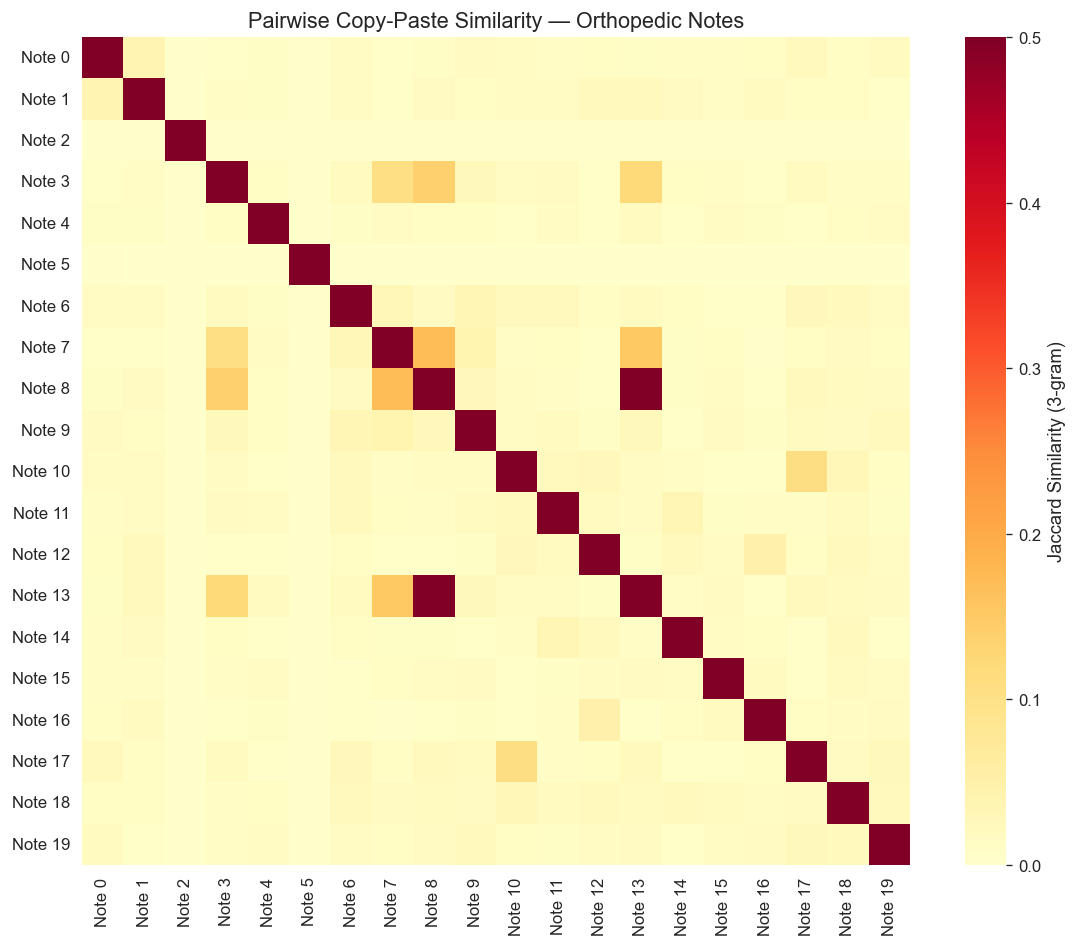


Pairwise similarity statistics (off-diagonal):
  Mean Jaccard:   0.012
  Median Jaccard: 0.009
  Max Jaccard:    0.581
  Pairs with >30% overlap: 1 / 780 (0.1%)
  Pairs with >50% overlap: 1 / 780 (0.1%)

Note: MTSamples has no longitudinal patient data, so this measures
between-patient template overlap, NOT within-patient copy-paste.
In a real EHR with successive notes per patient, overlap would be much higher.


In [6]:
# ============================================================
# Figure 3: Copy-Paste Detection via Jaccard Similarity
# (LECTURE FIGURE)
# ============================================================
#
# IMPORTANT NOTE: MTSamples contains standalone transcriptions with no
# longitudinal patient structure. Real EHR copy-paste happens between
# *successive notes for the same patient* — which we can't measure here.
# What we CAN measure is *between-patient template overlap*: how similar
# are notes from different patients within the same specialty? This is a
# weaker signal, but still informative about template-driven boilerplate.
#

def sentence_ngrams(text, n=3):
    """Extract character-level n-grams from sentences in a text."""
    sentences = sent_tokenize(text.lower())
    ngrams = set()
    for sent in sentences:
        words = sent.split()
        for i in range(len(words) - n + 1):
            ngrams.add(tuple(words[i:i+n]))
    return ngrams

def jaccard_similarity(set_a, set_b):
    """Compute Jaccard similarity between two sets."""
    if not set_a or not set_b:
        return 0.0
    return len(set_a & set_b) / len(set_a | set_b)

# Pick one specialty for analysis
TARGET_SPEC = 'Orthopedic'
spec_df = df[df['specialty'] == TARGET_SPEC].head(40).copy()

if len(spec_df) < 10:
    # Fallback: use the most common specialty
    TARGET_SPEC = df['specialty'].value_counts().index[0]
    spec_df = df[df['specialty'] == TARGET_SPEC].head(40).copy()

print(f"Analyzing {len(spec_df)} notes from '{TARGET_SPEC}' specialty.")

# Compute pairwise Jaccard similarity
ngram_sets = [sentence_ngrams(t) for t in spec_df['transcription'].values]
n = len(ngram_sets)
sim_matrix = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        sim_matrix[i, j] = jaccard_similarity(ngram_sets[i], ngram_sets[j])

# Heatmap of top-20
k = min(20, n)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    sim_matrix[:k, :k],
    cmap='YlOrRd', vmin=0, vmax=0.5,
    xticklabels=[f'Note {i}' for i in range(k)],
    yticklabels=[f'Note {i}' for i in range(k)],
    ax=ax, square=True,
    cbar_kws={'label': 'Jaccard Similarity (3-gram)'}
)
ax.set_title(f'Pairwise Copy-Paste Similarity — {TARGET_SPEC} Notes')
plt.tight_layout()
plt.savefig('figures/fig19_3_copypaste_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Statistics
upper_tri = sim_matrix[np.triu_indices(n, k=1)]
print(f"\nPairwise similarity statistics (off-diagonal):")
print(f"  Mean Jaccard:   {upper_tri.mean():.3f}")
print(f"  Median Jaccard: {np.median(upper_tri):.3f}")
print(f"  Max Jaccard:    {upper_tri.max():.3f}")
print(f"  Pairs with >30% overlap: {(upper_tri > 0.3).sum()} / {len(upper_tri)} "
      f"({100*(upper_tri > 0.3).mean():.1f}%)")
print(f"  Pairs with >50% overlap: {(upper_tri > 0.5).sum()} / {len(upper_tri)} "
      f"({100*(upper_tri > 0.5).mean():.1f}%)")
print(f"\nNote: MTSamples has no longitudinal patient data, so this measures")
print(f"between-patient template overlap, NOT within-patient copy-paste.")
print(f"In a real EHR with successive notes per patient, overlap would be much higher.")

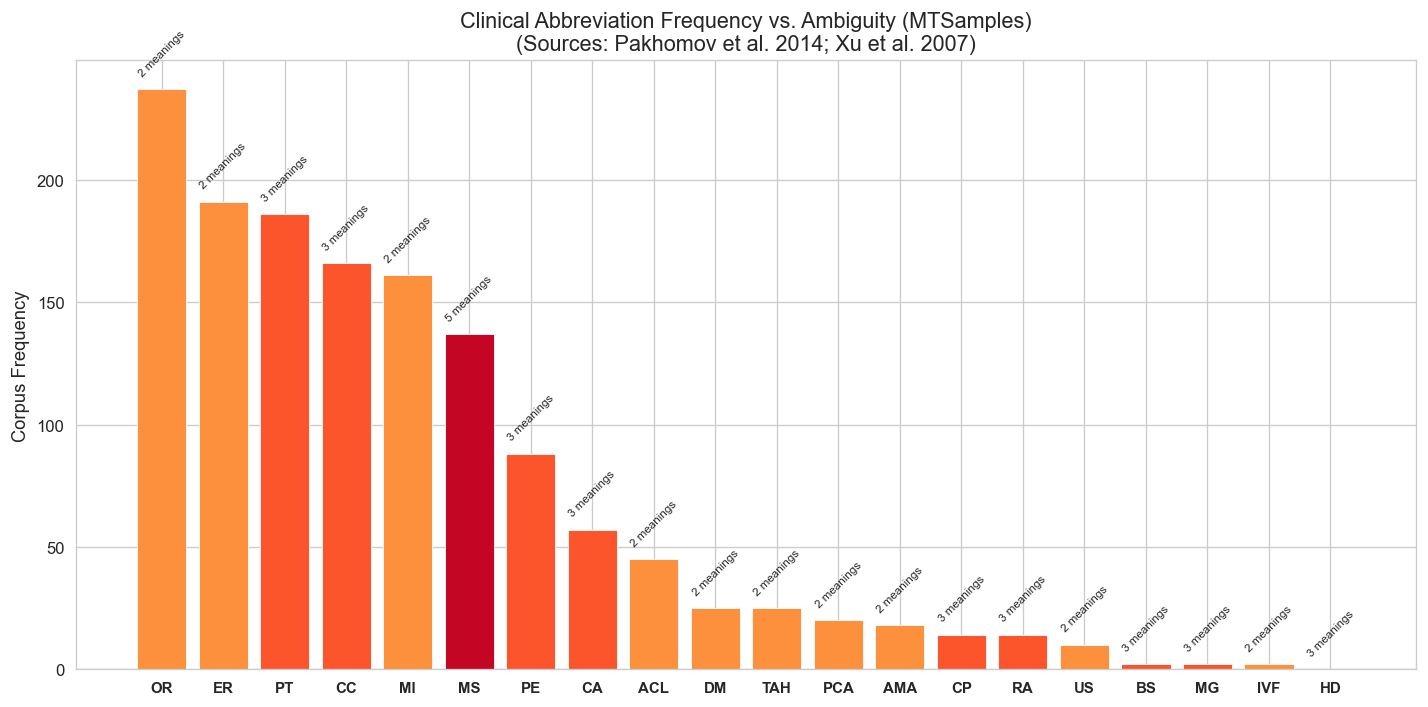


Top 5 most frequent ambiguous abbreviations:
  OR     (count=  237, meanings=2): operating room, odds ratio
  ER     (count=  191, meanings=2): emergency room, estrogen receptor
  PT     (count=  186, meanings=3): patient, physical therapy, prothrombin time
  CC     (count=  166, meanings=3): chief complaint, cubic centimeter, creatinine clearance
  MI     (count=  161, meanings=2): myocardial infarction, mitral insufficiency


In [7]:
# ============================================================
# Figure 4: Abbreviation Ambiguity (LECTURE FIGURE)
# ============================================================

# Clinical abbreviation dictionary — validated against published sense inventories:
#   - Pakhomov et al. (2014) JAMIA: 440 abbreviations from 352K clinical notes
#   - Xu et al. (2007) AMIA: 12 core ambiguous abbreviations from admission notes
#   - Moon et al. (2014): CARD sense inventory
#   - Cross-referenced with UMLS Metathesaurus (2024AB)
# Senses listed are those attested in clinical notes (not all UMLS senses).
ABBREV_DICT = {
    # --- Core 12 from Xu et al. (2007), validated in Pakhomov et al. (2014) ---
    'CA':  ['cancer/carcinoma', 'calcium', 'cardiac arrest'],
    'CC':  ['chief complaint', 'cubic centimeter', 'creatinine clearance'],
    'DM':  ['diabetes mellitus', 'diastolic murmur'],
    'HD':  ['hemodialysis', 'Huntington disease', 'hospital day'],
    'MI':  ['myocardial infarction', 'mitral insufficiency'],
    'PE':  ['pulmonary embolism', 'physical exam', 'pleural effusion'],
    'PT':  ['patient', 'physical therapy', 'prothrombin time'],
    'RA':  ['rheumatoid arthritis', 'right atrium', 'room air'],
    'MG':  ['milligram', 'myasthenia gravis', 'magnesium'],
    # --- Additional high-frequency from Pakhomov et al. (2014) ---
    'MS':  ['multiple sclerosis', 'mitral stenosis', 'morphine sulfate',
            'mental status', 'musculoskeletal'],
    'CP':  ['chest pain', 'cerebral palsy', 'cleft palate'],
    'BS':  ['blood sugar', 'bowel sounds', 'breath sounds'],
    'OR':  ['operating room', 'odds ratio'],
    'ER':  ['emergency room', 'estrogen receptor'],
    'AMA': ['against medical advice', 'American Medical Association'],
    'ACL': ['anterior cruciate ligament', 'Allen Cognitive Level'],
    'IVF': ['in vitro fertilization', 'intravenous fluid'],
    'PCA': ['patient-controlled analgesia', 'posterior cerebral artery'],
    'TAH': ['total abdominal hysterectomy', 'total artificial heart'],
    'US':  ['ultrasound', 'United States'],
}

# Count occurrences of each abbreviation in the corpus
# NOTE: We search the ORIGINAL case text, not uppercased, to avoid counting
# common English words like "or", "so", "us" as clinical abbreviations.
# We require the abbreviation to appear in ALL CAPS in the original text.
corpus_text = ' '.join(df['transcription'].values)

abbrev_data = []
for abbr, meanings in ABBREV_DICT.items():
    # Match only uppercase occurrences (e.g., "OR" but not "or")
    pattern = r'(?<![A-Za-z])' + re.escape(abbr) + r'(?![A-Za-z])'
    count = len(re.findall(pattern, corpus_text))
    abbrev_data.append({
        'abbreviation': abbr,
        'n_meanings': len(meanings),
        'corpus_count': count,
        'meanings': ', '.join(meanings)
    })

abbrev_df = pd.DataFrame(abbrev_data).sort_values('corpus_count', ascending=False)

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(
    range(len(abbrev_df)),
    abbrev_df['corpus_count'],
    color=[plt.cm.YlOrRd(0.25 + 0.12 * n) for n in abbrev_df['n_meanings']],
    edgecolor='white', linewidth=0.5
)

# Annotate with number of meanings
for i, (_, row) in enumerate(abbrev_df.iterrows()):
    ax.text(i, row['corpus_count'] + max(abbrev_df['corpus_count'])*0.02,
            f"{row['n_meanings']} meanings",
            ha='center', va='bottom', fontsize=7, rotation=45)

ax.set_xticks(range(len(abbrev_df)))
ax.set_xticklabels(abbrev_df['abbreviation'], fontsize=9, fontweight='bold')
ax.set_ylabel('Corpus Frequency')
ax.set_title('Clinical Abbreviation Frequency vs. Ambiguity (MTSamples)\n(Sources: Pakhomov et al. 2014; Xu et al. 2007)')
plt.tight_layout()
plt.savefig('figures/fig19_4_abbreviation_ambiguity.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 5 most frequent ambiguous abbreviations:")
for _, row in abbrev_df.head(5).iterrows():
    print(f"  {row['abbreviation']:5s}  (count={row['corpus_count']:5d}, meanings={row['n_meanings']}): {row['meanings']}")

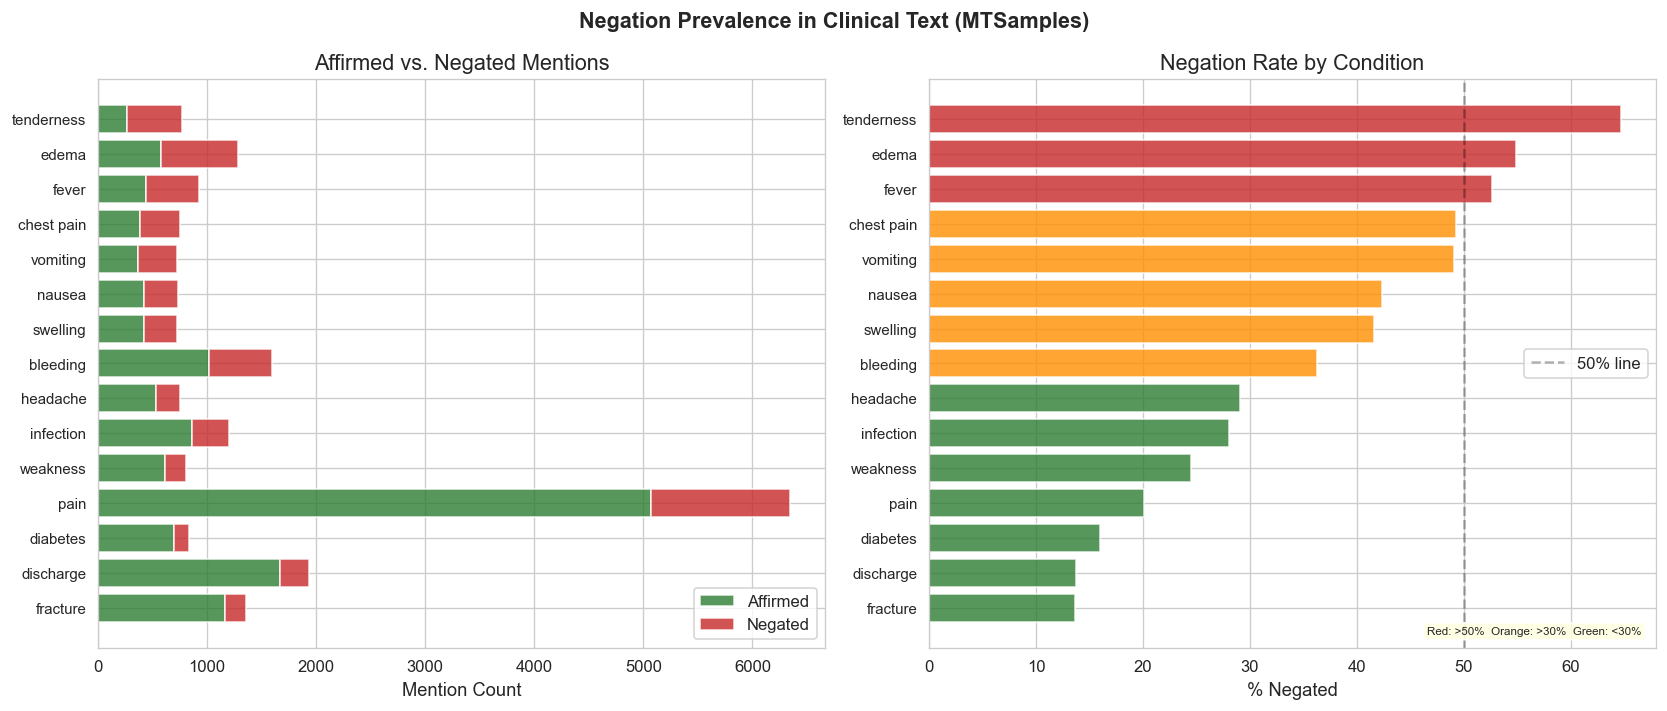


Conditions most often negated:
  rash                  66.0% negated (359/544 mentions)
  tenderness            64.8% negated (496/766 mentions)
  edema                 54.9% negated (705/1284 mentions)
  fever                 52.6% negated (487/925 mentions)
  chest pain            49.3% negated (372/755 mentions)


In [8]:
# ============================================================
# Figure 5: Negation Prevalence (LECTURE FIGURE)
# ============================================================

# Simple NegEx-style negation detector
NEGATION_TRIGGERS = [
    'no ', 'not ', 'denies ', 'denied ', 'without ', 'negative for ',
    'no evidence of ', 'no signs of ', 'absence of ', 'does not ',
    'did not ', 'never ', 'none ', 'nor ', 'fails to ', 'free of ',
    'rules out ', 'ruled out ', 'unremarkable ',
]

# Target medical conditions to search for
CONDITIONS = [
    'pain', 'fever', 'nausea', 'vomiting', 'swelling',
    'tenderness', 'edema', 'infection', 'bleeding', 'numbness',
    'weakness', 'dizziness', 'cough', 'rash', 'discharge',
    'fracture', 'shortness of breath', 'headache', 'chest pain',
    'diabetes',
]

def is_negated(text, condition_start, window=50):
    """Check if a condition mention is preceded by a negation trigger within a window.

    Limitation: This window-based approach can cross sentence boundaries, potentially
    attributing a negation from one sentence to a condition in the next. A production
    system would use sentence segmentation or dependency parsing. For this demo the
    error rate is low because most triggers and conditions co-occur within sentences.
    """
    preceding = text[max(0, condition_start - window):condition_start].lower()
    return any(trigger in preceding for trigger in NEGATION_TRIGGERS)

# Scan corpus
condition_counts = {c: {'affirmed': 0, 'negated': 0} for c in CONDITIONS}

for text in df['transcription'].values:
    text_lower = text.lower()
    for condition in CONDITIONS:
        # Find all occurrences
        start = 0
        while True:
            idx = text_lower.find(condition, start)
            if idx == -1:
                break
            if is_negated(text_lower, idx):
                condition_counts[condition]['negated'] += 1
            else:
                condition_counts[condition]['affirmed'] += 1
            start = idx + len(condition)

# Build DataFrame
neg_df = pd.DataFrame([
    {'condition': c, 'affirmed': v['affirmed'], 'negated': v['negated'],
     'total': v['affirmed'] + v['negated'],
     'pct_negated': v['negated'] / (v['affirmed'] + v['negated']) * 100
     if (v['affirmed'] + v['negated']) > 0 else 0}
    for c, v in condition_counts.items()
]).sort_values('total', ascending=False)

# Plot top 15 conditions
plot_df = neg_df.head(15).sort_values('pct_negated', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: stacked bar chart
ax = axes[0]
y_pos = range(len(plot_df))
ax.barh(y_pos, plot_df['affirmed'], color='#2E7D32', alpha=0.8, label='Affirmed')
ax.barh(y_pos, plot_df['negated'], left=plot_df['affirmed'],
        color='#C62828', alpha=0.8, label='Negated')
ax.set_yticks(y_pos)
ax.set_yticklabels(plot_df['condition'], fontsize=9)
ax.set_xlabel('Mention Count')
ax.set_title('Affirmed vs. Negated Mentions')
ax.legend(loc='lower right')

# Right: percent negated
ax = axes[1]
colors = ['#C62828' if p > 50 else '#FF8F00' if p > 30 else '#2E7D32'
          for p in plot_df['pct_negated']]
ax.barh(y_pos, plot_df['pct_negated'], color=colors, alpha=0.8)
ax.set_yticks(y_pos)
ax.set_yticklabels(plot_df['condition'], fontsize=9)
ax.set_xlabel('% Negated')
ax.set_title('Negation Rate by Condition')
ax.axvline(50, color='black', linestyle='--', alpha=0.3, label='50% line')
ax.legend()
ax.text(0.98, 0.02, 'Red: >50%  Orange: >30%  Green: <30%',
        transform=ax.transAxes, ha='right', va='bottom', fontsize=7,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

fig.suptitle('Negation Prevalence in Clinical Text (MTSamples)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/fig19_5_negation_prevalence.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nConditions most often negated:")
for _, row in neg_df.sort_values('pct_negated', ascending=False).head(5).iterrows():
    print(f"  {row['condition']:20s}  {row['pct_negated']:.1f}% negated "
          f"({row['negated']}/{row['total']} mentions)")

In [9]:
# ============================================================
# Cell 8: Section Segmentation Demo
# ============================================================

# Common section header patterns in clinical notes
SECTION_PATTERNS = [
    (r'(?i)\b(chief complaint|cc)\s*:', 'Chief Complaint'),
    (r'(?i)\b(history of present illness|hpi)\s*:', 'HPI'),
    (r'(?i)\b(past medical history|pmh|medical history)\s*:', 'Past Medical History'),
    (r'(?i)\b(medications|current medications|meds)\s*:', 'Medications'),
    (r'(?i)\b(allergies)\s*:', 'Allergies'),
    (r'(?i)\b(review of systems|ros)\s*:', 'Review of Systems'),
    (r'(?i)\b(physical exam|physical examination|pe)\s*:', 'Physical Exam'),
    (r'(?i)\b(assessment and plan|assessment|a\/p|plan)\s*:', 'Assessment & Plan'),
    (r'(?i)\b(labs|laboratory|results)\s*:', 'Labs/Results'),
    (r'(?i)\b(impression)\s*:', 'Impression'),
    (r'(?i)\b(findings)\s*:', 'Findings'),
    (r'(?i)\b(procedure|operative)\s*:', 'Procedure'),
]

def find_sections(text):
    """Find section headers in a clinical note."""
    sections = []
    for pattern, name in SECTION_PATTERNS:
        matches = list(re.finditer(pattern, text))
        for m in matches:
            sections.append((m.start(), name))
    return sorted(sections, key=lambda x: x[0])

# Analyze a sample of notes
sample_notes = df.sample(min(200, len(df)), random_state=SEED)
section_found = Counter()
notes_with_sections = 0

for text in sample_notes['transcription'].values:
    sections = find_sections(text)
    if sections:
        notes_with_sections += 1
    for _, name in sections:
        section_found[name] += 1

print(f"Notes with at least one recognized section header: "
      f"{notes_with_sections}/{len(sample_notes)} ({100*notes_with_sections/len(sample_notes):.1f}%)")
print(f"\nSection header frequency (in {len(sample_notes)} notes):")
for section, count in section_found.most_common():
    print(f"  {section:25s}  {count:4d}  ({100*count/len(sample_notes):.1f}%)")

# Show a concrete example
print("\n" + "="*60)
print("Example: Sections found in one note")
print("="*60)
for text in df['transcription'].values[:50]:
    sections = find_sections(text)
    if len(sections) >= 3:
        print(f"\nDetected sections: {[s[1] for s in sections]}")
        print(f"Note preview (first 300 chars):\n{text[:300]}...")
        break

Notes with at least one recognized section header: 151/200 (75.5%)

Section header frequency (in 200 notes):
  Procedure                   108  (54.0%)
  Assessment & Plan            54  (27.0%)
  Medications                  40  (20.0%)
  Impression                   35  (17.5%)
  Physical Exam                34  (17.0%)
  Past Medical History         33  (16.5%)
  HPI                          32  (16.0%)
  Allergies                    26  (13.0%)
  Review of Systems            25  (12.5%)
  Findings                     25  (12.5%)
  Chief Complaint              15  (7.5%)
  Labs/Results                  4  (2.0%)

Example: Sections found in one note

Detected sections: ['Medications', 'Allergies', 'Assessment & Plan', 'Assessment & Plan']
Note preview (first 300 chars):
SUBJECTIVE:,  This 23-year-old white female presents with complaint of allergies.  She used to have allergies when she lived in Seattle but she thinks they are worse here.  In the past, she has tried Claritin, and Zyr

In [10]:
# ============================================================
# Bonus: Concrete Text Examples Across Domains
# Loads small samples from HuggingFace to illustrate the taxonomy
# ============================================================
#
# Datasets used:
#   - MedRAG/textbooks: Medical textbook snippets (USMLE reference texts)
#   - MedRAG/pubmed: PubMed abstract snippets (23.9M articles)
#   - avaliev/chat_doctor: Real patient-doctor conversations (HealthCareMagic)
#
# These complement MTSamples (clinical transcriptions) to show
# the four text categories from the lecture taxonomy.

from datasets import load_dataset

print("Loading text examples from HuggingFace (small samples)...\n")

# --- Medical Textbook (pedagogical, formal, structured) ---
try:
    tb = load_dataset("MedRAG/textbooks", split="train", streaming=True)
    tb_iter = iter(tb)
    tb_examples = [next(tb_iter) for _ in range(3)]
    print("=" * 70)
    print("MEDICAL TEXTBOOK (MedRAG/textbooks)")
    print("  Source: 18 USMLE reference textbooks, chunked to ~182 tokens")
    print("=" * 70)
    for ex in tb_examples[:2]:
        title = ex.get('title', ex.get('id', ''))
        content = ex.get('content', ex.get('contents', str(ex)))[:300]
        print(f"\n  [{title}]")
        print(f"  {content}...")
except Exception as e:
    print(f"  Could not load textbooks: {e}")

# --- PubMed Abstract (formal, research-oriented) ---
try:
    pm = load_dataset("MedRAG/pubmed", split="train", streaming=True)
    pm_iter = iter(pm)
    pm_examples = [next(pm_iter) for _ in range(3)]
    print("\n" + "=" * 70)
    print("PUBMED ABSTRACT (MedRAG/pubmed)")
    print("  Source: 23.9M articles with titles and abstracts")
    print("=" * 70)
    for ex in pm_examples[:2]:
        title = ex.get('title', ex.get('id', ''))
        content = ex.get('content', ex.get('contents', str(ex)))[:300]
        print(f"\n  [{title}]")
        print(f"  {content}...")
except Exception as e:
    print(f"  Could not load PubMed: {e}")

# --- Patient-Doctor Conversation (informal, colloquial) ---
try:
    cd = load_dataset("avaliev/chat_doctor", split="train", streaming=True)
    cd_iter = iter(cd)
    cd_examples = [next(cd_iter) for _ in range(3)]
    print("\n" + "=" * 70)
    print("PATIENT-DOCTOR CONVERSATION (avaliev/chat_doctor)")
    print("  Source: 100K real conversations from HealthCareMagic.com")
    print("=" * 70)
    for ex in cd_examples[:2]:
        inp = ex.get('input', '')[:300]
        out = ex.get('output', '')[:200]
        print(f"\n  Patient: {inp}...")
        print(f"  Doctor:  {out}...")
except Exception as e:
    print(f"  Could not load ChatDoctor: {e}")

# --- Clinical Notes (already loaded: MTSamples) ---
print("\n" + "=" * 70)
print("CLINICAL TRANSCRIPTION (MTSamples — already loaded above)")
print("  Source: ~5K de-identified medical transcriptions")
print("=" * 70)
sample = df.sample(1, random_state=SEED+1).iloc[0]
print(f"\n  Specialty: {sample['specialty']}")
print(f"  {sample['transcription'][:300]}...")

print("\n" + "=" * 70)
print("COMPARE: Notice how vocabulary, formality, sentence structure,")
print("and abbreviation density differ across these four text types.")
print("A model trained on one will not transfer well to the others.")
print("=" * 70)



Loading text examples from HuggingFace (small samples)...



README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

MEDICAL TEXTBOOK (MedRAG/textbooks)
  Source: 18 USMLE reference textbooks, chunked to ~182 tokens

  [Anatomy_Gray]
  What is anatomy? Anatomy includes those structures that can be seen grossly (without the aid of magnification) and microscopically (with the aid of magnification). Typically, when used by itself, the term anatomy tends to mean gross or macroscopic anatomy—that is, the study of structures that can be...

  [Anatomy_Gray]
  Observation and visualization are the primary techniques a student should use to learn anatomy. Anatomy is much more than just memorization of lists of names. Although the language of anatomy is important, the network of information needed to visualize the position of physical structures in a patien...


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/1166 [00:00<?, ?it/s]


PUBMED ABSTRACT (MedRAG/pubmed)
  Source: 23.9M articles with titles and abstracts

  [[Biochemical studies on camomile components/III. In vitro studies about the antipeptic activity of (--)-alpha-bisabolol (author's transl)].]
  (--)-alpha-Bisabolol has a primary antipeptic action depending on dosage, which is not caused by an alteration of the pH-value. The proteolytic activity of pepsin is reduced by 50 percent through addition of bisabolol in the ratio of 1/0.5. The antipeptic action of bisabolol only occurs in case of d...

  [[Demonstration of tumor inhibiting properties of a strongly immunostimulating low-molecular weight substance. Comparative studies with ifosfamide on the immuno-labile DS carcinosarcoma. Stimulation of the autoimmune activity for approx. 20 days by BA 1, a N-(2-cyanoethylene)-urea. Novel prophylactic possibilities].]
  A report is given on the recent discovery of outstanding immunological properties in BA 1 [N-(2-cyanoethylene)-urea] having a (low) molecular

README.md: 0.00B [00:00, ?B/s]


PATIENT-DOCTOR CONVERSATION (avaliev/chat_doctor)
  Source: 100K real conversations from HealthCareMagic.com

  Patient: Hi.  My son had an appendectomy within the passed 24 hours.  Previous to that he had been sick with stomach virus type symptoms for 5 days.  He now has had two loose bowel movements within the past four hours that has blood in them.  Is this to be expected or do I need to take him back to the ER?  I...
  Doctor:  Hello dear, Thank you for your contact to Chat Doctor. I read and understand your concern. I am Chat Doctor answering your concern. Yes, you need to visit to the doctor immediately. It is not the viru...

  Patient: hello...i have a severe gambling addiction that I would like to quit with some assistance from naltrexone.   Ive done lots of research on it and am wanting to look into getting a prescription.I have also used vicodin daily for about 4 years about 20-30 mg daily.  I have not had any vicodin for 5 day...
  Doctor:  Degree understand your concerns 

## Discussion Questions

1. **Copy-paste and ML:** If you're training a model to predict patient outcomes from clinical notes, and 70% of the note text is copy-pasted from previous encounters, how would you handle this? What are the risks of *not* handling it?

2. **Abbreviation disambiguation:** You encounter the abbreviation "MS" in a clinical note. What additional information would you need to disambiguate it? How might a model learn this disambiguation automatically?

3. **Negation as a feature:** We showed that many conditions appear more often negated than affirmed. Could the *pattern* of what a clinician explicitly negates be informative for prediction? (Hint: a clinician writing "denies chest pain" chose to ask about chest pain for a reason.)

4. **Data access trade-offs:** Compare the trade-offs between working with MTSamples (free, no PHI, but synthetic/curated) vs. MIMIC (real ICU data, but credentialed access) vs. your institution's EHR (most realistic, but IRB required). When is each appropriate?

---

**Next:** Lecture 20 — Clinical & Biomedical NLP: Modeling